In [1]:
import os
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
import torch.utils.data as DataLoader
from torchvision import datasets
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from torch.utils.data.dataloader import DataLoader
from torch.utils.checkpoint import checkpoint

Check CUDA

In [ ]:
import torch

if torch.cuda.is_available():
    print(f"{torch.cuda.get_device_name(0)}")
else:
    print("No Gpu")


GPU is available: NVIDIA GeForce RTX 4080 SUPER


In [ ]:
import torch
import random
import timm
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torch.nn as nn
from collections import defaultdict
import numpy as np
from torch.optim.lr_scheduler import StepLR
from PIL import Image, ImageFilter

# Datasets
train_data_dir = 'train'
val_data_dir = 'val'  

num_samples_per_class = 0.9

# Custom undersampled dataset
class UndersampledImageFolder(datasets.ImageFolder):
    def __init__(self, root, transform=None, target_transform=None, num_samples_per_class=None):
        super().__init__(root, transform=transform, target_transform=target_transform)
        self.num_samples_per_class = num_samples_per_class
        self.samples, self.targets = self.undersample()

    def undersample(self):
        class_indices = defaultdict(list)
        for idx, target in enumerate(self.targets):
            class_indices[target].append(idx)

        selected_indices = []
        for class_idx, indices in class_indices.items():
            total = len(indices)
            if isinstance(self.num_samples_per_class, float) and 0 < self.num_samples_per_class <= 1:
                num_to_sample = int(self.num_samples_per_class * total)
            elif isinstance(self.num_samples_per_class, int) and self.num_samples_per_class < total:
                num_to_sample = self.num_samples_per_class
            else:
                num_to_sample = total

            sampled_indices = random.sample(indices, num_to_sample)
            selected_indices.extend(sampled_indices)

        new_samples = [self.samples[idx] for idx in selected_indices]
        new_targets = [self.targets[idx] for idx in selected_indices]
        return new_samples, new_targets

# Custom transformation (Cropping, smoothing, sharpening, etc.) -> For training
class CustomTransform:
    def __init__(self):
        self.transforms = transforms.Compose([
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
            transforms.RandomRotation(20),
            transforms.RandomPerspective(distortion_scale=0.5, p=0.5, interpolation=3),
            transforms.Lambda(self.noise_removal),
            transforms.Lambda(self.sharpen_image),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

    def __call__(self, x):
        return self.transforms(x)

    def noise_removal(self, img):
        return img.filter(ImageFilter.GaussianBlur(radius=1))

    def sharpen_image(self, img):
        sharpness_filter = ImageFilter.UnsharpMask(radius=2, percent=150, threshold=3)
        return img.filter(sharpness_filter)

# Define transforms
train_transform = CustomTransform()
#Make sure validation data does not change
val_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load undersampled dataset
dataset = UndersampledImageFolder(root=train_data_dir, transform=train_transform, num_samples_per_class=num_samples_per_class)

# Split testing and validation
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


# Load model and prepare training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Model is vit_base_patch16_2224
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, 4)  # For 4 disease classes
model.to(device)

#Define optimizer, loss function, scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
lr_scheduler = StepLR(optimizer, step_size=10, gamma=0.7)

# Training loop
best_val_loss = np.inf
early_stopping_patience = 10
epochs_without_improvement = 0

for epoch in range(100):
    model.train()
    total_train_loss = 0
    total_train_correct = 0
    total_train_samples = 0

    for img, label in train_loader:
        img, label = img.to(device), label.to(device)
        optimizer.zero_grad()
        outputs = model(img)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train_correct += (predicted == label).sum().item()
        total_train_samples += label.size(0)

    epoch_train_loss = total_train_loss / len(train_loader)
    epoch_train_accuracy = 100 * total_train_correct / total_train_samples

    model.eval()
    total_val_loss = 0
    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for img, label in val_loader:
            img, label = img.to(device), label.to(device)
            outputs = model(img)
            loss = criterion(outputs, label)
            total_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val_correct += (predicted == label).sum().item()
            total_val_samples += label.size(0)

    epoch_val_loss = total_val_loss / len(val_loader)
    epoch_val_accuracy = 100 * total_val_correct / total_val_samples

    print(f"Epoch {epoch+1}/100, "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%")

    lr_scheduler.step()

    
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        #Prevent overfit using early stop
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print(f"Stopped at Epoch: {epoch+1}")
            break


Class distribution after undersampling and splitting: {3: 5607, 1: 4047, 2: 6054, 0: 5701}
Epoch 1/100, Train Loss: 1.2858, Train Acc: 37.78%, Val Loss: 1.3187, Val Acc: 42.49%
Epoch 2/100, Train Loss: 1.1107, Train Acc: 47.37%, Val Loss: 1.2399, Val Acc: 41.47%
Epoch 3/100, Train Loss: 1.0001, Train Acc: 53.47%, Val Loss: 0.8792, Val Acc: 59.76%
Epoch 4/100, Train Loss: 0.9126, Train Acc: 57.54%, Val Loss: 0.8686, Val Acc: 60.31%
Epoch 5/100, Train Loss: 0.8620, Train Acc: 59.93%, Val Loss: 0.8037, Val Acc: 63.08%
Epoch 6/100, Train Loss: 0.8357, Train Acc: 60.56%, Val Loss: 0.9722, Val Acc: 57.94%
Epoch 7/100, Train Loss: 0.8022, Train Acc: 62.79%, Val Loss: 0.9832, Val Acc: 55.88%
Epoch 8/100, Train Loss: 0.7794, Train Acc: 64.11%, Val Loss: 0.7960, Val Acc: 62.67%
Epoch 9/100, Train Loss: 0.7631, Train Acc: 64.73%, Val Loss: 0.7686, Val Acc: 65.12%
Epoch 10/100, Train Loss: 0.7473, Train Acc: 66.01%, Val Loss: 0.7520, Val Acc: 65.78%
Epoch 11/100, Train Loss: 0.6785, Train Acc: 69.

In [20]:
# Save the model after training is finished
torch.save(model.state_dict(), 'trained_model.pth')

Model Evaluation (Confusion Matrix and Classification Report)

Class names: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


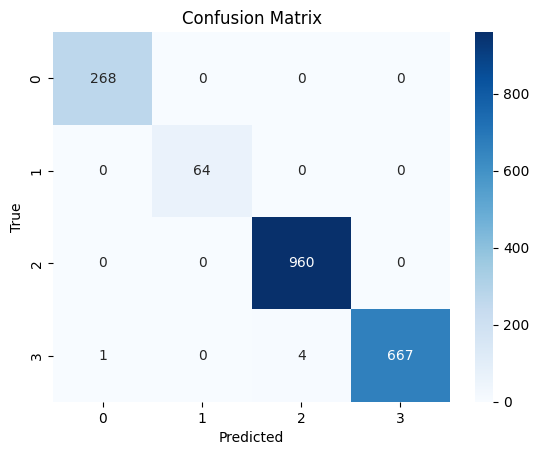

                  precision    recall  f1-score   support

    MildDemented       1.00      1.00      1.00       268
ModerateDemented       1.00      1.00      1.00        64
     NonDemented       1.00      1.00      1.00       960
VeryMildDemented       1.00      0.99      1.00       672

        accuracy                           1.00      1964
       macro avg       1.00      1.00      1.00      1964
    weighted avg       1.00      1.00      1.00      1964



In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import timm
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import random
from collections import defaultdict


model = timm.create_model('vit_base_patch16_224', pretrained=False)
model.head = torch.nn.Linear(model.head.in_features, 4)  

model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cpu')))  # Path to your trained model
model.to(torch.device("cpu"))
model.eval()

#Testing data using 30% of Val dataset
val_transform = transforms.Compose([
    transforms.Resize(224),  
    transforms.CenterCrop(224),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])


val_data_dir = 'val'
val_dataset = datasets.ImageFolder(root=val_data_dir, transform=val_transform)

val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = val_dataset.classes  
moderate_demented_class_idx = class_names.index("ModerateDemented") 

class_indices = defaultdict(list)
for idx, target in enumerate(val_dataset.targets):
    class_indices[target].append(idx)


subset_indices = []

subset_indices.extend(class_indices[moderate_demented_class_idx])

for class_idx, indices in class_indices.items():
    if class_idx != moderate_demented_class_idx:
        sample_size = int(len(indices) * 0.30)  
        sampled_indices = random.sample(indices, sample_size)
        subset_indices.extend(sampled_indices)

# Create a Subset Dataset using the sampled indices
subset_val_dataset = torch.utils.data.Subset(val_dataset, subset_indices)
subset_val_loader = DataLoader(subset_val_dataset, batch_size=32, shuffle=False)

all_preds = []
all_labels = []

#Perform inference and gather predictions and true labels
with torch.no_grad():  
    for img, label in subset_val_loader:
        img, label = img.to(device), label.to(device)
        outputs = model(img)_, predicted = torch.max(outputs, 1)      
        all_preds.extend(predicted.cpu().numpy())  # Save predictions
        all_labels.extend(label.cpu().numpy())  # Save true labels

# Step 6: Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Step 7: Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 8: Print classification report
print(classification_report(all_labels, all_preds, target_names=val_dataset.classes))


Testing in Prediction

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5005665].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832

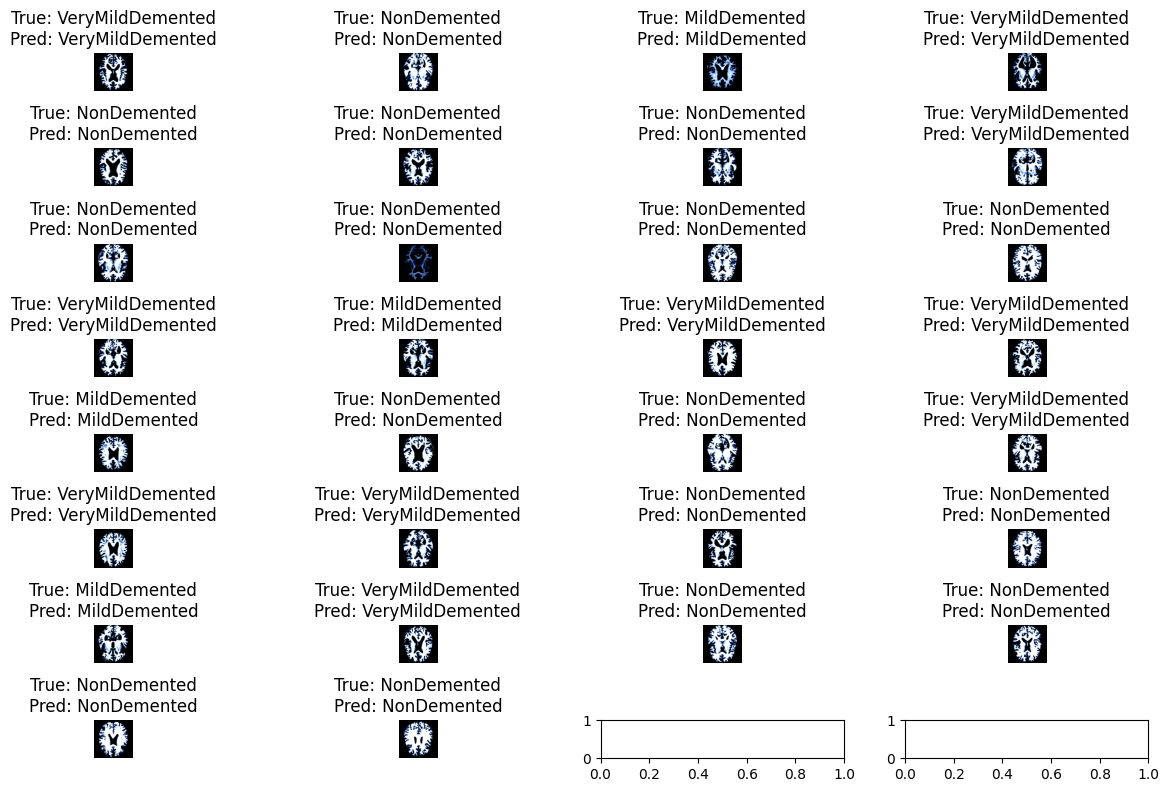

In [ ]:
test_data_dir = 'val'  

test_transform = transforms.Compose([
    transforms.Resize(224),  
    transforms.CenterCrop(224),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])

# Load the testing dataset
test_dataset = datasets.ImageFolder(root=test_data_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True) \

# Set model to evaluation mode
model.eval()

# Get a batch of testing data
data_iter = iter(test_loader)
images, labels = next(data_iter)  # Use next() instead of .next()

# Move images and labels to the device
images, labels = images.to(device), labels.to(device)

# Get predictions from the model
outputs = model(images)
_, preds = torch.max(outputs, 1)


images_per_row = 4
num_images = min(30, len(images))  

num_rows = num_images // images_per_row
if num_images % images_per_row != 0:
    num_rows += 1


fig, axes = plt.subplots(num_rows, images_per_row, figsize=(12, 8))

# Flatten the axes array to make indexing easier
axes = axes.flatten()

# Access the original test_dataset to get classes (subfolder names)
test_classes = test_dataset.classes  # Access the original ImageFolder classes (subfolder names)

for i in range(num_images):
    ax = axes[i]
    img = images[i].cpu().numpy().transpose(1, 2, 0)  # Convert to HWC format for displaying
    ax.imshow(img)
    ax.set_title(f'True: {test_classes[labels[i]]}\nPred: {test_classes[preds[i]]}')
    ax.axis('off')

# Adjust layout for better spacing and make sure everything fits
plt.tight_layout(pad=1.0)
plt.show()
